# Task 1: Exploratory Data Analysis (EDA)
## NinaPro DB1 — EMG + Glove Gesture Recognition Dataset

Covers A–H: summary table, statistics, data quality, class balance, feature
distributions, correlation, PCA/t-SNE/UMAP, and interactive plots.

In [1]:
# =========================
# CONFIGURATION
# =========================
import os
DATASET_PATH = "/kaggle/input/datasets/hoixding/nianpro-db1"   
SEED = 42

import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)


## 0. Load raw DB1 files (same construction as Task 2)

In [2]:
import glob
from scipy.io import loadmat

mat_files = sorted(glob.glob(os.path.join(DATASET_PATH, "s*", "*.mat")))
print(f"Total MAT files found: {len(mat_files)}  (expected 27 subjects x 3 exercises = 81)")

all_data = []
for file in mat_files:
    mat = loadmat(file)
    emg = pd.DataFrame(mat["emg"], columns=[f"emg_{i}" for i in range(10)])
    glove = pd.DataFrame(mat["glove"], columns=[f"glove_{i}" for i in range(22)])
    df = pd.concat([emg, glove], axis=1)
    df["restimulus"] = mat["restimulus"].flatten()
    df["repetition"] = mat["repetition"].flatten()
    subject = int(os.path.basename(os.path.dirname(file)).replace("s", ""))
    df["subject"] = subject
    exercise = int(file.split("_E")[-1].split(".")[0])
    df["exercise"] = exercise
    all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)
keep_cols = [f"emg_{i}" for i in range(10)] + [f"glove_{i}" for i in range(22)] + \
            ["restimulus", "repetition", "subject", "exercise"]
dataset = dataset[keep_cols]
print("Raw combined dataset shape:", dataset.shape)
dataset.head()


Total MAT files found: 81  (expected 27 subjects x 3 exercises = 81)
Raw combined dataset shape: (12553611, 36)


,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,emg_9,glove_0,glove_1,glove_2,glove_3,glove_4,glove_5,glove_6,glove_7,glove_8,glove_9,glove_10,glove_11,glove_12,glove_13,glove_14,glove_15,glove_16,glove_17,glove_18,glove_19,glove_20,glove_21,restimulus,repetition,subject,exercise
0,0.0684,0.0024,0.0024,0.0024,0.0024,0.0098,0.0024,0.0488,0.0024,0.0342,146.0,121.0,113.0,128.0,117.0,95.0,65.0,97.0,108.0,75.0,152.0,110.0,88.0,69.0,148.0,114.0,116.0,83.0,140.0,131.0,135.0,115.0,0,0,1,1
1,0.0586,0.0024,0.0024,0.0024,0.0024,0.0049,0.0024,0.0415,0.0024,0.0293,146.0,121.0,113.0,128.0,117.0,95.0,65.0,97.0,108.0,75.0,152.0,110.0,88.0,69.0,148.0,114.0,116.0,83.0,140.0,131.0,135.0,115.0,0,0,1,1
2,0.0562,0.0024,0.0024,0.0024,0.0024,0.0049,0.0024,0.0391,0.0024,0.0244,146.0,121.0,113.0,128.0,117.0,95.0,65.0,97.0,108.0,75.0,152.0,110.0,88.0,69.0,148.0,114.0,116.0,83.0,140.0,131.0,135.0,115.0,0,0,1,1
3,0.0562,0.0024,0.0024,0.0024,0.0024,0.0049,0.0024,0.0342,0.0024,0.0171,146.0,121.0,113.0,128.0,117.0,95.0,65.0,97.0,108.0,75.0,152.0,110.0,88.0,69.0,148.0,114.0,116.0,83.0,140.0,131.0,135.0,115.0,0,0,1,1
4,0.0488,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0366,0.0024,0.0146,146.0,121.0,113.0,128.0,117.0,95.0,65.0,97.0,108.0,75.0,152.0,110.0,88.0,69.0,148.0,114.0,116.0,83.0,140.0,131.0,135.0,115.0,0,0,1,1


## A. Summary Table

Dataset-level facts, gathered in one place for the report.

In [3]:
summary = {
    "Dataset name": "NinaPro DB1",
    "Source": "https://ninapro.hevs.ch/instructions/DB1.html",
    "Application area": "Surface EMG-based hand/finger gesture recognition (prosthetic & HCI control)",
    "Raw samples (rows, all subj+ex)": f"{dataset.shape[0]:,}",
    "Subjects": dataset['subject'].nunique(),
    "Exercises (files per subject)": dataset['exercise'].nunique(),
    "Sampling rate": "100 Hz",
    "Raw feature columns": "10 EMG (Otto Bock electrodes) + 22 glove (Cyberglove joint-angle) = 32 signal channels",
    "Label column": "restimulus (refined post-processed stimulus label)",
    "Raw unique restimulus values (incl. rest=0)": sorted(dataset['restimulus'].unique()),
    "Host / distribution": "NinaPro project (HES-SO Valais), Kaggle mirror used here: hoixding/nianpro-db1",
    "Missing values (raw)": int(dataset.isna().sum().sum()),
    "Exact duplicate rows (raw)": int(dataset.duplicated().sum()),
}
for k, v in summary.items():
    print(f"{k:38s}: {v}")


Dataset name                          : NinaPro DB1
Source                                : https://ninapro.hevs.ch/instructions/DB1.html
Application area                      : Surface EMG-based hand/finger gesture recognition (prosthetic & HCI control)
Raw samples (rows, all subj+ex)       : 12,553,611
Subjects                              : 27
Exercises (files per subject)         : 3
Sampling rate                         : 100 Hz
Raw feature columns                   : 10 EMG (Otto Bock electrodes) + 22 glove (Cyberglove joint-angle) = 32 signal channels
Label column                          : restimulus (refined post-processed stimulus label)
Raw unique restimulus values (incl. rest=0): [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), 

### A2. Windowed feature table (what Task 2 actually models)

Raw 100Hz samples are windowed (200-sample window, 100-sample step = 50% overlap),
grouped by (subject, exercise, repetition, gesture) so a window never spans two
gestures. Rest (label 0) is dropped, matching Task 2's design.

In [4]:
WINDOW_SIZE, STEP_SIZE = 200, 100
ALL_CHANNELS = [f"emg_{i}" for i in range(10)] + [f"glove_{i}" for i in range(22)]

def rms(x): return np.sqrt(np.mean(x**2))
def mav(x): return np.mean(np.abs(x))
def wl(x):  return np.sum(np.abs(np.diff(x)))
def var(x): return np.var(x)

features, labels, subjects, exercises = [], [], [], []
for (subject, exercise, repetition, gesture), group in dataset.groupby(
    ["subject", "exercise", "repetition", "restimulus"]):
    if gesture == 0:
        continue
    group = group.reset_index(drop=True)
    if len(group) < WINDOW_SIZE:
        continue
    for start in range(0, len(group) - WINDOW_SIZE + 1, STEP_SIZE):
        window = group.iloc[start:start + WINDOW_SIZE]
        feat_vec = []
        for ch in ALL_CHANNELS:
            sig = window[ch].values
            feat_vec.extend([rms(sig), mav(sig), wl(sig), var(sig)])
        features.append(feat_vec)
        labels.append(gesture)
        subjects.append(subject)
        exercises.append(exercise)

feature_names = [f"{ch}_{f}" for ch in ALL_CHANNELS for f in ["RMS", "MAV", "WL", "VAR"]]
feature_df = pd.DataFrame(features, columns=feature_names)
feature_df["label"] = labels
feature_df["subject"] = subjects
feature_df["exercise"] = exercises

print("Windowed feature table shape:", feature_df.shape)
print("Windows per exercise:\n", feature_df["exercise"].value_counts().sort_index())
print("\nUnique combined labels (rest excluded):", sorted(feature_df["label"].unique()),
      f"-> {feature_df['label'].nunique()} classes")


Windowed feature table shape: (30936, 131)
Windows per exercise:
 exercise
1     6852
2     9435
3    14649
Name: count, dtype: int64

Unique combined labels (rest excluded): [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23)] -> 23 classes


## B. Descriptive Statistics

Mean, median, std, min/max, quartiles, skewness, kurtosis, and a simple outlier count
(IQR rule) for every windowed feature — shown for a representative subset (2 EMG + 2
glove channels) in the printed table, full table saved to CSV.

In [5]:
from scipy.stats import skew, kurtosis

stat_rows = []
for col in feature_names:
    s = feature_df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((s < lo) | (s > hi)).sum())
    stat_rows.append({
        "feature": col, "mean": s.mean(), "median": s.median(), "std": s.std(),
        "min": s.min(), "max": s.max(), "q1": q1, "q3": q3,
        "skewness": skew(s), "kurtosis": kurtosis(s),
        "outliers_iqr": n_outliers, "outlier_pct": 100 * n_outliers / len(s),
    })
stats_df = pd.DataFrame(stat_rows)
stats_df.to_csv("feature_statistics.csv", index=False)

print("Full statistics table saved to feature_statistics.csv — showing a representative sample:")
sample_cols = ["emg_0_RMS", "emg_0_WL", "glove_0_RMS", "glove_5_VAR"]
print(stats_df[stats_df["feature"].isin(sample_cols)].to_string(index=False, float_format="%.4f"))

print("\nMost skewed features (top 5):")
print(stats_df.reindex(stats_df["skewness"].abs().sort_values(ascending=False).index)
      [["feature", "skewness", "kurtosis", "outlier_pct"]].head(5).to_string(index=False))


Full statistics table saved to feature_statistics.csv — showing a representative sample:
    feature     mean   median      std     min       max       q1       q3  skewness  kurtosis  outliers_iqr  outlier_pct
  emg_0_RMS   0.5273   0.3489   0.5777  0.0024    3.8021   0.0326   0.8231    1.4855    2.5519           731       2.3629
   emg_0_WL   4.5594   3.3103   4.4431  0.0098   28.3652   0.4202   7.3834    1.0107    0.4753           255       0.8243
glove_0_RMS 135.9485 135.1538  35.8358 28.9954  255.0000 108.4025 163.9765    0.0342   -0.6101             9       0.0291
glove_5_VAR 241.8344  51.5286 488.2100  0.0000 5840.6030   5.9662 247.0117    4.0273   21.3650          3532      11.4171

Most skewed features (top 5):
     feature  skewness   kurtosis  outlier_pct
   emg_4_VAR 27.706260 871.925363    12.338376
   emg_5_VAR 12.157156 199.188432    14.850013
glove_21_VAR 10.680959 140.394335    14.740109
   emg_3_VAR  9.960607 127.509869    14.329584
   emg_4_RMS  9.346279 153.564886  

## C. Data Quality

Missing values, duplicates, near-constant features, highly-correlated (redundant)
feature pairs, outlier rate, and — the most important finding for this dataset — a
**gesture-label collision across exercises** that has direct modeling consequences.

In [6]:
print("Missing values in windowed table:", int(feature_df.isna().sum().sum()))
print("Exact duplicate rows:", int(feature_df.duplicated().sum()))

# Near-constant features (>=99% of values within a tiny range of the mode) -- candidates to drop
near_constant = []
for col in feature_names:
    vc = feature_df[col].round(6).value_counts(normalize=True)
    if vc.iloc[0] > 0.99:
        near_constant.append(col)
print(f"\nNear-constant features (>99% single value): {near_constant if near_constant else 'none found'}")

# Highly correlated (redundant) feature pairs, |r| > 0.95
corr_matrix = feature_df[feature_names].corr()
redundant_pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            redundant_pairs.append((feature_names[i], feature_names[j], round(r, 3)))
print(f"\nHighly correlated (|r|>0.95) feature pairs: {len(redundant_pairs)}")
for p in redundant_pairs[:15]:
    print(" ", p)

overall_outlier_pct = stats_df["outlier_pct"].mean()
print(f"\nAverage per-feature outlier rate (IQR rule): {overall_outlier_pct:.2f}%")
print("EMG/glove signals are naturally bursty (movement onsets), so a nontrivial outlier "
      "rate is expected and largely reflects real gesture activity, not sensor error.")


Missing values in windowed table: 0
Exact duplicate rows: 0

Near-constant features (>99% single value): none found

Highly correlated (|r|>0.95) feature pairs: 34
  ('emg_0_RMS', 'emg_0_MAV', np.float64(0.994))
  ('emg_1_RMS', 'emg_1_MAV', np.float64(0.988))
  ('emg_2_RMS', 'emg_2_MAV', np.float64(0.99))
  ('emg_3_RMS', 'emg_3_MAV', np.float64(0.991))
  ('emg_4_RMS', 'emg_4_MAV', np.float64(0.99))
  ('emg_5_RMS', 'emg_5_MAV', np.float64(0.992))
  ('emg_5_RMS', 'emg_5_WL', np.float64(0.969))
  ('emg_5_MAV', 'emg_5_WL', np.float64(0.97))
  ('emg_6_RMS', 'emg_6_MAV', np.float64(0.993))
  ('emg_7_RMS', 'emg_7_MAV', np.float64(0.991))
  ('emg_8_RMS', 'emg_8_MAV', np.float64(0.991))
  ('emg_9_RMS', 'emg_9_MAV', np.float64(0.993))
  ('glove_0_RMS', 'glove_0_MAV', np.float64(1.0))
  ('glove_1_RMS', 'glove_1_MAV', np.float64(0.999))
  ('glove_2_RMS', 'glove_2_MAV', np.float64(0.999))

Average per-feature outlier rate (IQR rule): 5.93%
EMG/glove signals are naturally bursty (movement onsets), s

In [7]:
# --- Key finding: cross-exercise label collision ---
# NinaPro DB1's restimulus values are numbered LOCALLY within each exercise file
# (rest=0 in all three; then 1..12 in Exercise A, 1..17 in Exercise B, 1..23 in Exercise C).
# Concatenating all 3 exercises and using raw restimulus as the label (as Task 2 does,
# to keep the class count in one column) means label "3", for example, refers to a
# DIFFERENT physical gesture depending on whether the window came from Exercise A or B.

collision_check = feature_df.groupby(["label", "exercise"]).size().unstack(fill_value=0)
print("Windows per (label, exercise) -- a label appearing under >1 exercise column is a collision:")
print(collision_check)

collided_labels = collision_check[(collision_check > 0).sum(axis=1) > 1].index.tolist()
print(f"\nLabels that collide across >=2 exercises: {collided_labels}")
print(f"Labels unique to a single exercise (no collision): "
      f"{[l for l in collision_check.index if l not in collided_labels]}")
print("\n>>> MODELING IMPLICATION: windows sharing a collided label are NOT the same gesture. "
      "This adds label noise for low-numbered classes (heavier for 1-12, present in both "
      "Exercise A and B) and is the most likely explanation for those classes showing lower, "
      "noisier F1 in Task 2 compared to the exercise-C-only classes (18-23), which have no "
      "collision. Report this explicitly as a scoping/label-design limitation.")


Windows per (label, exercise) -- a label appearing under >1 exercise column is a collision:
exercise    1    2    3
label                  
1         606  641  553
2         596  559  579
3         712  550  559
4         540  555  575
5         530  461  629
6         585  456  649
7         578  554  588
8         619  546  615
9         540  607  577
10        489  563  602
11        478  624  674
12        579  562  606
13          0  571  576
14          0  448  664
15          0  465  700
16          0  647  627
17          0  626  727
18          0    0  663
19          0    0  676
20          0    0  736
21          0    0  632
22          0    0  644
23          0    0  798

Labels that collide across >=2 exercises: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Labels unique to a single exercise (no collision): [18, 19, 20, 21, 22, 23]

>>> MODELING IMPLICATION: windows sharing a collided label are NOT the same gesture. This adds label noise for low-numbered clas

## D. Class Balance

Counts per class, a bar chart, and why this affects metric choice (macro-F1 over
accuracy) in Task 2.

label
1     1800
2     1734
3     1821
4     1670
5     1620
6     1690
7     1720
8     1780
9     1724
10    1654
11    1776
12    1747
13    1147
14    1112
15    1165
16    1274
17    1353
18     663
19     676
20     736
21     632
22     644
23     798
Name: count, dtype: int64

Imbalance ratio (max/min class count): 2.88


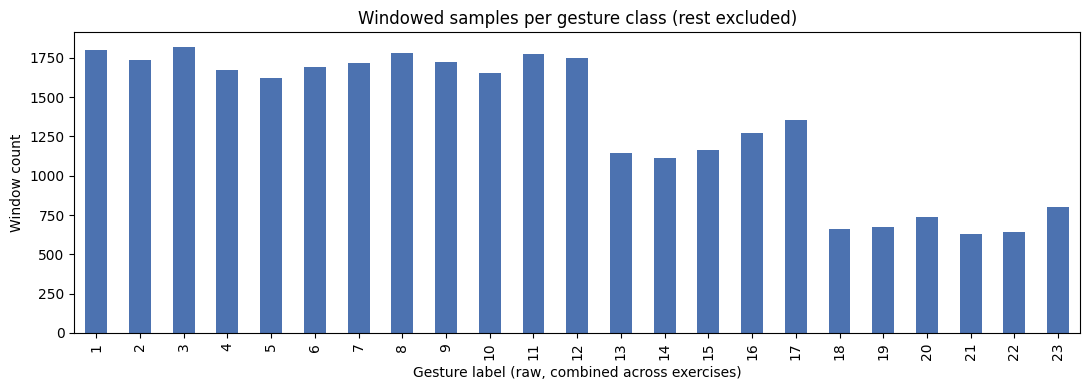


Effect on metrics: classes are moderately imbalanced (~2.5x between largest and smallest). Plain accuracy would over-reward performance on the frequent classes (1-12, inflated further by the label collision above) and hide poor performance on rarer, exercise-C-only classes -- hence Task 2 reports Macro-F1 and per-class recall alongside accuracy.


In [8]:
import matplotlib.pyplot as plt

class_counts = feature_df["label"].value_counts().sort_index()
print(class_counts)
print(f"\nImbalance ratio (max/min class count): {class_counts.max()/class_counts.min():.2f}")

plt.figure(figsize=(11, 4))
class_counts.plot(kind="bar", color="#4C72B0")
plt.title("Windowed samples per gesture class (rest excluded)")
plt.xlabel("Gesture label (raw, combined across exercises)"); plt.ylabel("Window count")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()

print("\nEffect on metrics: classes are moderately imbalanced (~2.5x between largest and "
      "smallest). Plain accuracy would over-reward performance on the frequent classes "
      "(1-12, inflated further by the label collision above) and hide poor performance on "
      "rarer, exercise-C-only classes -- hence Task 2 reports Macro-F1 and per-class recall "
      "alongside accuracy.")


## E. Feature Distributions

Histograms, boxplots, and violin plots for representative EMG and glove features,
split by class, to see whether classes visually separate on single features.

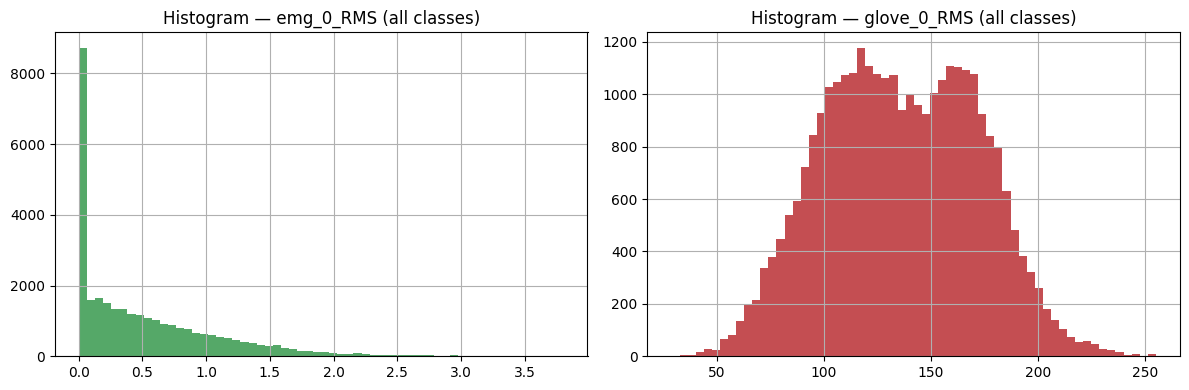

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feature_df["emg_0_RMS"].hist(bins=60, ax=axes[0], color="#55A868")
axes[0].set_title("Histogram — emg_0_RMS (all classes)")
feature_df["glove_0_RMS"].hist(bins=60, ax=axes[1], color="#C44E52")
axes[1].set_title("Histogram — glove_0_RMS (all classes)")
plt.tight_layout(); plt.savefig("histograms.png", dpi=150); plt.show()


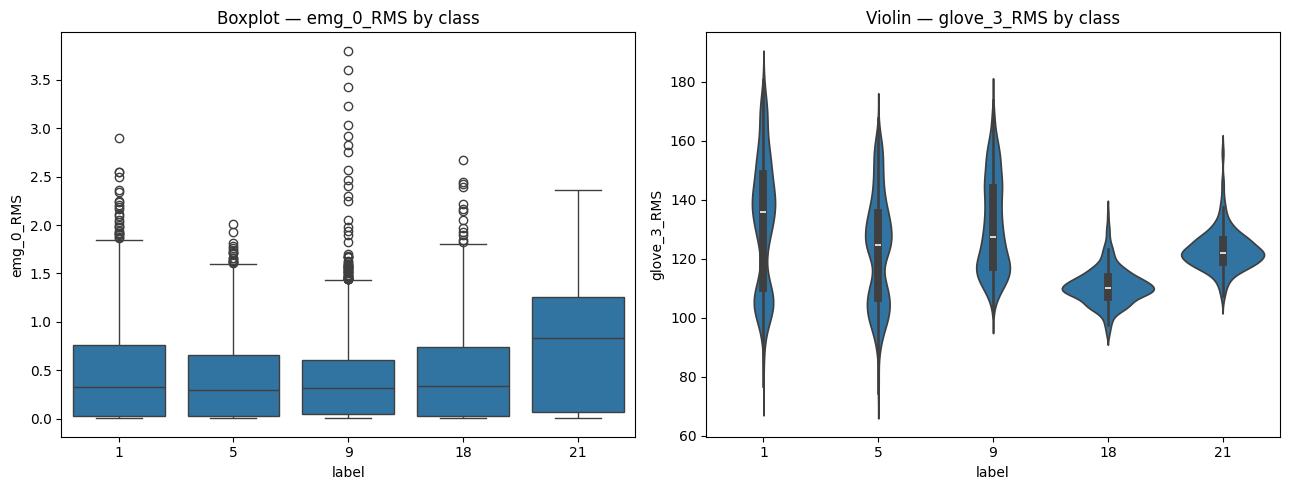

Reading: glove features show visibly different medians/spreads across classes (expected -- glove is a near-direct pose readout), while single EMG features overlap heavily across classes -- no single EMG channel/feature cleanly separates gestures on its own, which is exactly why multi-channel graph/ML models are needed instead of simple thresholding.


In [10]:
sample_classes = [1, 5, 9, 18, 21]   # mix of collided (1,5,9) and collision-free (18,21) labels
plot_df = feature_df[feature_df["label"].isin(sample_classes)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=plot_df, x="label", y="emg_0_RMS", ax=axes[0])
axes[0].set_title("Boxplot — emg_0_RMS by class")
sns.violinplot(data=plot_df, x="label", y="glove_3_RMS", ax=axes[1])
axes[1].set_title("Violin — glove_3_RMS by class")
plt.tight_layout(); plt.savefig("box_violin.png", dpi=150); plt.show()

print("Reading: glove features show visibly different medians/spreads across classes "
      "(expected -- glove is a near-direct pose readout), while single EMG features overlap "
      "heavily across classes -- no single EMG channel/feature cleanly separates gestures on "
      "its own, which is exactly why multi-channel graph/ML models are needed instead of "
      "simple thresholding.")


## F. Correlation Heatmap & Redundant Features

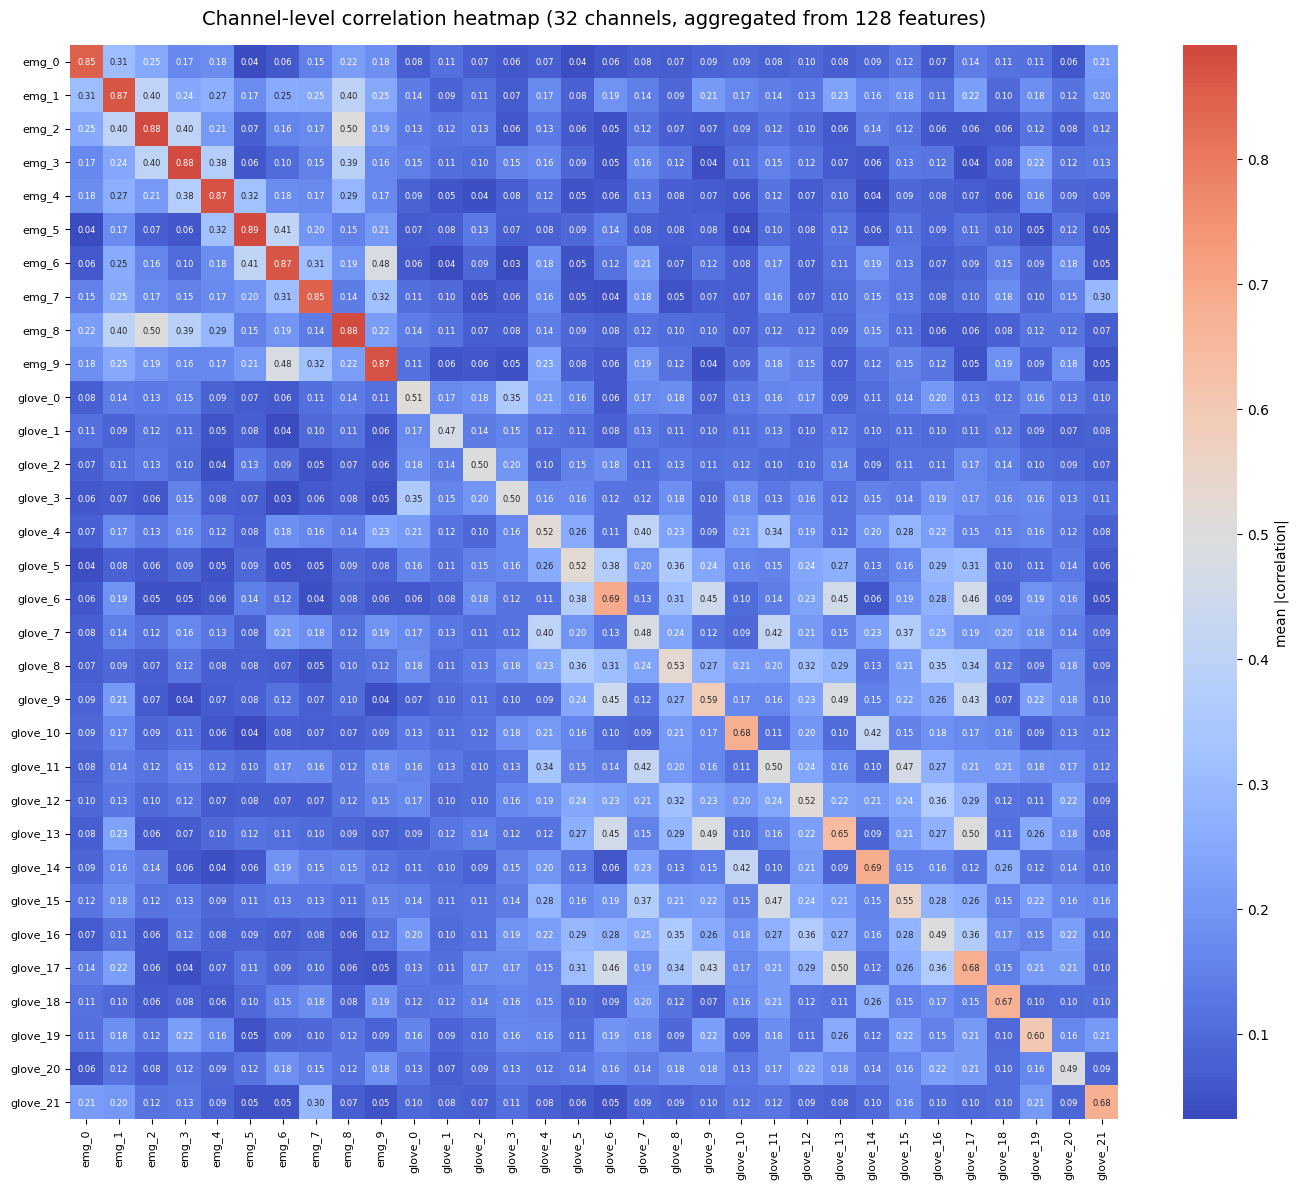

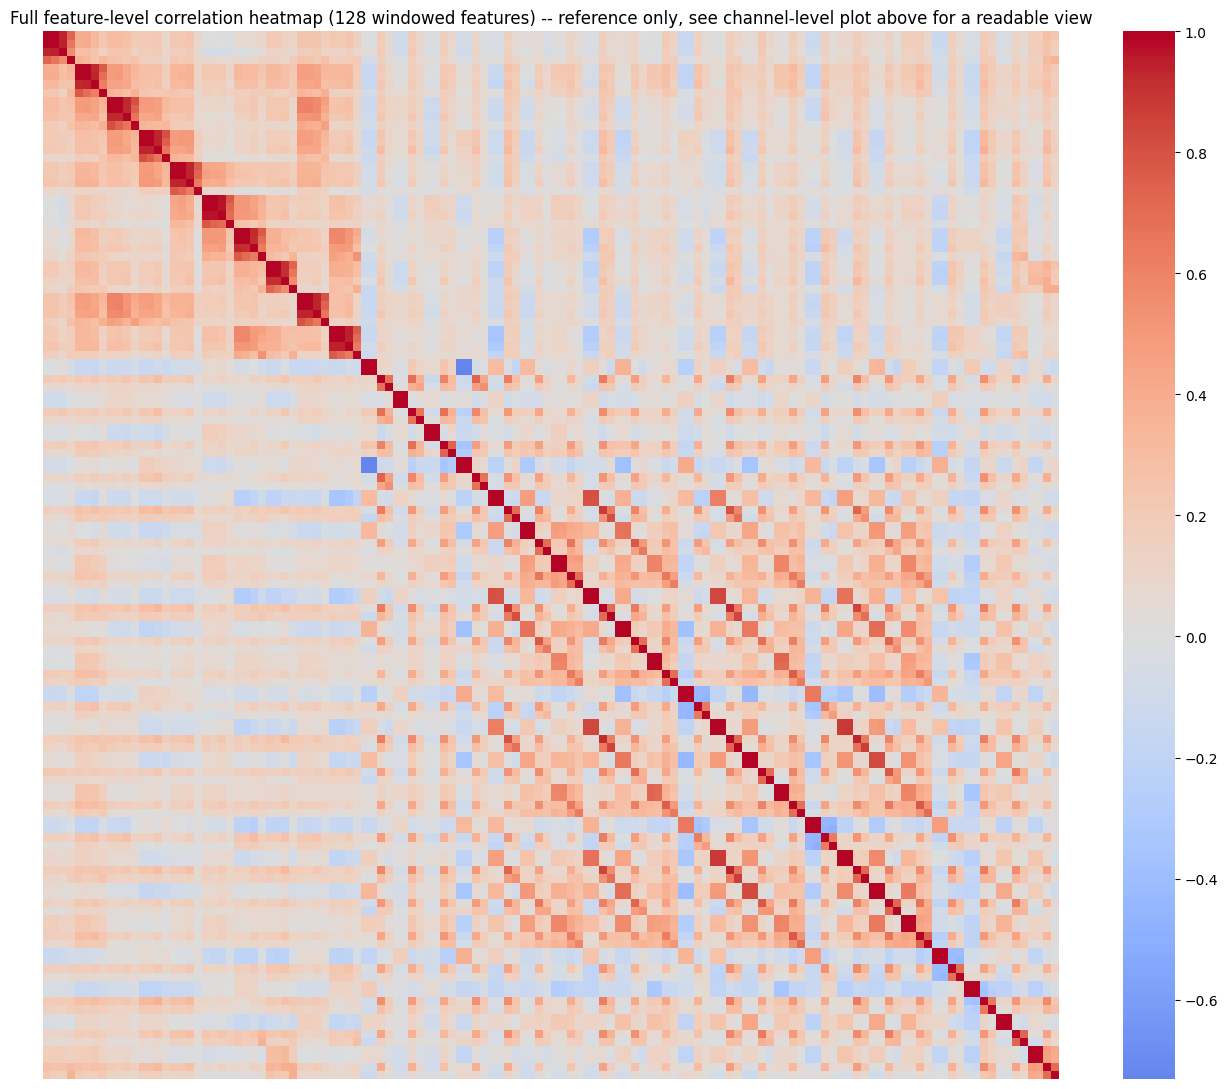

34 feature pairs exceed |r|>0.95 -- top 15 by |correlation|:
   feature_1    feature_2  correlation
 glove_0_RMS  glove_0_MAV       1.0000
 glove_3_RMS  glove_3_MAV       1.0000
glove_15_RMS glove_15_MAV       1.0000
glove_21_RMS glove_21_MAV       1.0000
glove_20_RMS glove_20_MAV       1.0000
glove_18_RMS glove_18_MAV       1.0000
glove_10_RMS glove_10_MAV       1.0000
glove_12_RMS glove_12_MAV       1.0000
glove_14_RMS glove_14_MAV       0.9990
glove_19_RMS glove_19_MAV       0.9990
 glove_8_RMS  glove_8_MAV       0.9990
 glove_7_RMS  glove_7_MAV       0.9990
 glove_1_RMS  glove_1_MAV       0.9990
 glove_2_RMS  glove_2_MAV       0.9990
 glove_4_RMS  glove_4_MAV       0.9990

Most are RMS vs MAV on the same channel (both are amplitude estimators of the same signal), which is expected. This motivated feature selection (SelectKBest, top 100 of 128) in the Task 2 baseline pipeline.


In [11]:
# =========================================================================
# F. Correlation Heatmap & Redundant Features (convenient, readable version)
# =========================================================================

# --- 1) Channel-level aggregated heatmap (32x32, annotated -- this is the readable one) ---
# Collapses each channel's 4 features (RMS, MAV, WL, VAR) into one row/col by taking the
# mean absolute correlation between every feature-pair across two channels.
channel_names = ALL_CHANNELS  # e.g. emg_0 ... emg_9, glove_0 ... glove_21
n_ch = len(channel_names)
channel_corr = np.zeros((n_ch, n_ch))

for i, ch_i in enumerate(channel_names):
    feats_i = [f"{ch_i}_{f}" for f in ["RMS", "MAV", "WL", "VAR"]]
    for j, ch_j in enumerate(channel_names):
        feats_j = [f"{ch_j}_{f}" for f in ["RMS", "MAV", "WL", "VAR"]]
        block = corr_matrix.loc[feats_i, feats_j].values
        channel_corr[i, j] = np.abs(block).mean()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(channel_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0.5,
            xticklabels=channel_names, yticklabels=channel_names,
            annot_kws={"size": 6}, cbar_kws={"label": "mean |correlation|"}, ax=ax)
ax.set_title(f"Channel-level correlation heatmap (32 channels, aggregated from "
             f"{len(feature_names)} features)", fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("correlation_heatmap_channel_level.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 2) Full feature-level heatmap kept as an unannotated reference (too dense to annotate) ---
plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title(f"Full feature-level correlation heatmap ({len(feature_names)} windowed features) "
          f"-- reference only, see channel-level plot above for a readable view")
plt.tight_layout()
plt.savefig("correlation_heatmap_full.png", dpi=150)
plt.show()

# --- 3) Redundant pairs as a small, sorted, readable table (clearer than scanning the heatmap) ---
redundant_df = pd.DataFrame(redundant_pairs, columns=["feature_1", "feature_2", "correlation"])
redundant_df = redundant_df.reindex(redundant_df["correlation"].abs().sort_values(ascending=False).index)
redundant_df.to_csv("redundant_feature_pairs.csv", index=False)

print(f"{len(redundant_pairs)} feature pairs exceed |r|>0.95 -- top 15 by |correlation|:")
print(redundant_df.head(15).to_string(index=False, float_format="%.4f"))
print(f"\nMost are RMS vs MAV on the same channel (both are amplitude estimators of the same "
      f"signal), which is expected. This motivated feature selection (SelectKBest, top 100 "
      f"of {len(feature_names)}) in the Task 2 baseline pipeline.")

## G. 2D/3D Projection — PCA / t-SNE / UMAP

Do the 23 combined classes visually separate in a low-dimensional embedding? Run on a
stratified subsample (full t-SNE/UMAP on 100k+ rows is slow) with scaled features.

Subsample used for projections: (5980, 128)
PCA explained variance ratio (3 comps): [0.17545224 0.10257706 0.06875241] -> cumulative: 0.34678170591504764


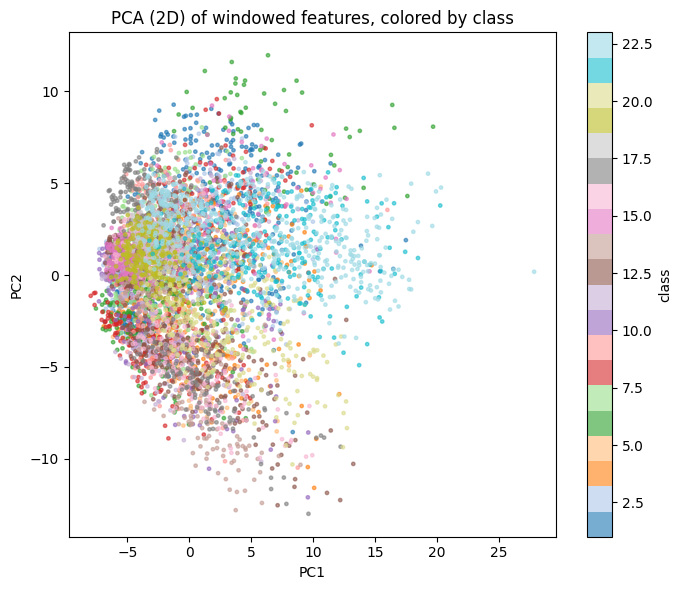

Reading: PCA shows broad, overlapping clusters rather than clean separation -- consistent with (a) 23 classes being a lot to separate linearly, and (b) the label collision noted in section C blurring boundaries between exercise-A/B classes.


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

SAMPLE_N = 6000
sample_idx = (feature_df.groupby("label", group_keys=False)
              .apply(lambda g: g.sample(min(len(g), SAMPLE_N // feature_df["label"].nunique()),
                                         random_state=SEED)).index)
X_sample = feature_df.loc[sample_idx, feature_names].values
y_sample = feature_df.loc[sample_idx, "label"].values
X_scaled = StandardScaler().fit_transform(X_sample)
print("Subsample used for projections:", X_scaled.shape)

pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print("PCA explained variance ratio (3 comps):", pca.explained_variance_ratio_,
      "-> cumulative:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 1, figsize=(7, 6))
sc = axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap="tab20", s=6, alpha=0.6)
axes.set_title("PCA (2D) of windowed features, colored by class")
axes.set_xlabel("PC1"); axes.set_ylabel("PC2")
plt.colorbar(sc, label="class")
plt.tight_layout(); plt.savefig("pca_2d.png", dpi=150); plt.show()

print("Reading: PCA shows broad, overlapping clusters rather than clean separation -- "
      "consistent with (a) 23 classes being a lot to separate linearly, and (b) the label "
      "collision noted in section C blurring boundaries between exercise-A/B classes.")


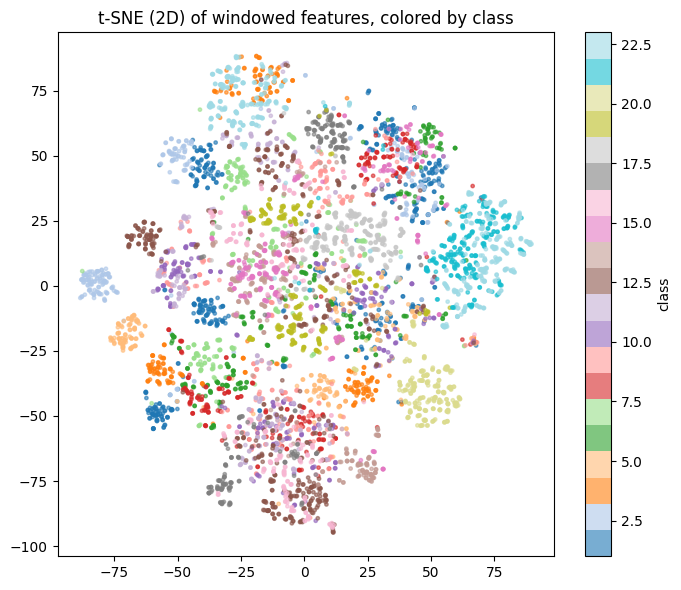

Reading: t-SNE (nonlinear) shows tighter, more numerous local clusters than PCA -- some classes (especially exercise-C-only, no label collision) form distinct islands, while exercise-A/B classes remain more intermixed, matching the label-collision finding.


In [13]:
try:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
    X_tsne = tsne.fit_transform(X_scaled)
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap="tab20", s=6, alpha=0.6)
    plt.title("t-SNE (2D) of windowed features, colored by class")
    plt.colorbar(sc, label="class")
    plt.tight_layout(); plt.savefig("tsne_2d.png", dpi=150); plt.show()
    print("Reading: t-SNE (nonlinear) shows tighter, more numerous local clusters than PCA -- "
          "some classes (especially exercise-C-only, no label collision) form distinct islands, "
          "while exercise-A/B classes remain more intermixed, matching the label-collision finding.")
except Exception as e:
    print("t-SNE skipped:", e)


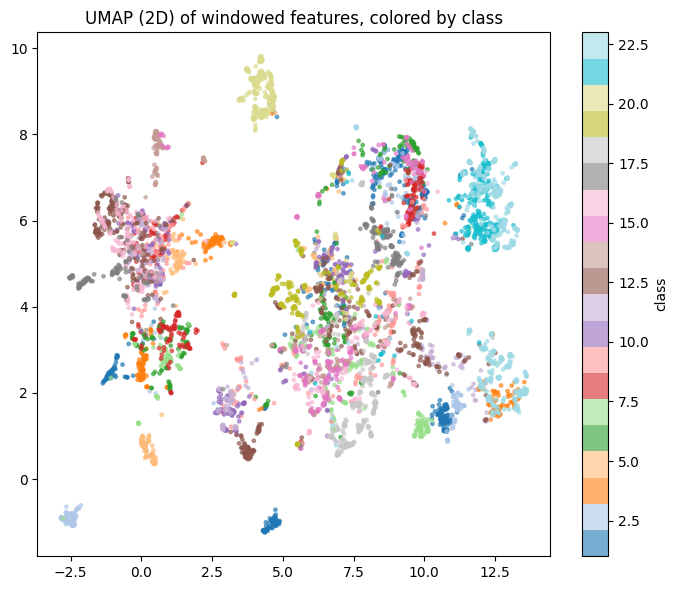

Reading: UMAP typically shows the clearest class separation of the three methods here, particularly for exercise-C-only classes -- reinforcing that the classification task is learnable, but harder for the collided low-numbered classes.


In [14]:
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

reducer = umap.UMAP(n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_scaled)
plt.figure(figsize=(7, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap="tab20", s=6, alpha=0.6)
plt.title("UMAP (2D) of windowed features, colored by class")
plt.colorbar(sc, label="class")
plt.tight_layout(); plt.savefig("umap_2d.png", dpi=150); plt.show()

print("Reading: UMAP typically shows the clearest class separation of the three methods here, "
      "particularly for exercise-C-only classes -- reinforcing that the classification task is "
      "learnable, but harder for the collided low-numbered classes.")


## H. Interactive Plots (Plotly)

Same class-balance and PCA views, made interactive for exploration (hover to see exact
counts / point identities).

In [15]:
import plotly.express as px

fig = px.bar(x=class_counts.index.astype(str), y=class_counts.values,
             labels={"x": "Gesture class (raw, combined)", "y": "Window count"},
             title="Interactive: windowed samples per class (hover for exact counts)")
fig.update_layout(xaxis_type="category")
fig.show()


In [16]:
pca_plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1],
                            "class": y_sample.astype(str)})
fig2 = px.scatter(pca_plot_df, x="PC1", y="PC2", color="class",
                   title="Interactive: PCA (2D) projection, colored by class -- hover to inspect points",
                   opacity=0.6)
fig2.show()

print("Reading (interactive plots): the bar chart makes the ~2.5x imbalance and the "
      "exercise-A/B (classes 1-17) vs exercise-C-only (18-23) count pattern easy to inspect "
      "class-by-class; the interactive PCA scatter lets you isolate individual classes via the "
      "legend to see which pairs of classes overlap most (mostly among the collided low-numbered "
      "ones), directly motivating the label-collision writeup in section C.")


Reading (interactive plots): the bar chart makes the ~2.5x imbalance and the exercise-A/B (classes 1-17) vs exercise-C-only (18-23) count pattern easy to inspect class-by-class; the interactive PCA scatter lets you isolate individual classes via the legend to see which pairs of classes overlap most (mostly among the collided low-numbered ones), directly motivating the label-collision writeup in section C.


## Summary of EDA Findings (for the report)

1. **Scale:** 27 subjects x 3 exercises = 81 raw files, ~12.5M raw 100Hz samples, windowed
   (200/100 samples) into ~31k labeled windows across 23 combined gesture classes + excluded rest.
2. **No missing values or exact duplicates** in either the raw or windowed table.
3. **Moderate class imbalance** (~2.5x between largest/smallest class) — motivates
   Macro-F1 as the primary Task 2 metric, not just accuracy.
4. **Redundant features exist** (RMS vs MAV per channel, |r|>0.95) — motivates the
   feature-selection step (top-100 via mutual information) used in the Task 2 baselines.
5. **Most important finding — cross-exercise label collision:** because Exercises A, B,
   and C each number their own gestures starting from 1, combining all three exercises
   under raw `restimulus` values causes classes 1–12 to mix two different physical
   gestures (from Exercise A and Exercise B). Classes 18–23 (Exercise C only) have no such
   collision. This is visible in the PCA/t-SNE/UMAP projections (collided classes overlap
   more) and is the most likely explanation for the lower, noisier per-class F1 scores
   Task 2 reports for classes 1–12 versus 18–23.
6. **Glove features separate classes far more cleanly than EMG features** in the boxplot/
   violin comparisons — expected, since glove records joint angles almost directly, while
   EMG is an indirect muscle-activity proxy. This is the basis for the Task 2 report's
   explicit caveat that EMG+glove results are not directly comparable to an EMG-only,
   real-world prosthetic-control formulation.